In [1]:
suppressPackageStartupMessages({
library(recipes)
library(tidyverse)
library(embed)
library(ggforce)
library(tidymodels)
library(mixOmics)
library(fastICA)
library(bestNormalize)
})
theme_set(cowplot::theme_cowplot())
options(repr.plot.width=15,repr.plot.height=9)

# Dimensionality Reduction

# Dataset

In [2]:
library(beans)

In [3]:
head(beans)

area,perimeter,major_axis_length,minor_axis_length,aspect_ratio,eccentricity,convex_area,equiv_diameter,extent,solidity,roundness,compactness,shape_factor_1,shape_factor_2,shape_factor_3,shape_factor_4,class
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
28395,610.291,208.1781,173.8887,1.197191,0.5498122,28715,190.1411,0.7639225,0.9888560,0.9580271,0.9133578,0.007331506,0.003147289,0.8342224,0.9987239,seker
28734,638.018,200.5248,182.7344,1.097356,0.4117853,29172,191.2728,0.7839681,0.9849856,0.8870336,0.9538608,0.006978659,0.003563624,0.9098505,0.9984303,seker
29380,624.110,212.8261,175.9311,1.209713,0.5627273,29690,193.4109,0.7781132,0.9895588,0.9478495,0.9087742,0.007243912,0.003047733,0.8258706,0.9990661,seker
30008,645.884,210.5580,182.5165,1.153638,0.4986160,30724,195.4671,0.7826813,0.9766957,0.9039364,0.9283288,0.007016729,0.003214562,0.8617944,0.9941988,seker
30140,620.134,201.8479,190.2793,1.060798,0.3336797,30417,195.8965,0.7730980,0.9908933,0.9848771,0.9705155,0.006697010,0.003664972,0.9419004,0.9991661,seker
30279,634.927,212.5606,181.5102,1.171067,0.5204007,30600,196.3477,0.7756885,0.9895098,0.9438518,0.9237260,0.007020065,0.003152779,0.8532696,0.9992358,seker


In [4]:
data_split <- initial_split(beans, prop=0.7, strata=class)

train = training(data_split)
test <- testing(data_split)

In [5]:
table(test$class)


barbunya   bombay     cali dermason    horoz    seker     sira 
     377      149      501     1068      571      616      804 

In [6]:
rec <- recipe(class ~ ., data=training(data_split)) |>
step_zv(all_numeric_predictors()) |>
step_orderNorm(all_numeric_predictors()) |>
step_normalize(all_numeric_predictors())

In [7]:
prep(rec) |>
bake(new_data = NULL) |>
head()

area,perimeter,major_axis_length,minor_axis_length,aspect_ratio,eccentricity,convex_area,equiv_diameter,extent,solidity,roundness,compactness,shape_factor_1,shape_factor_2,shape_factor_3,shape_factor_4,class
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
-0.22707620,-0.23018275,-0.16469484,-0.23910970,-0.20754041,-0.20754041,-0.22559124,-0.22707620,-0.8822719,-0.1943821,0.3836976,0.22397181,0.22262276,0.18580716,0.22397181,0.59773080,barbunya
-0.04290947,0.09303214,-0.04185585,-0.01631711,-0.14312389,-0.14312389,-0.03974877,-0.04290947,-0.0650482,-0.5539308,-0.6375409,0.12612765,0.02526677,0.07005982,0.12612765,-0.47992550,barbunya
0.18527169,0.18152486,-0.21076825,0.68236860,-1.20737228,-1.20737228,0.19223703,0.18527169,-0.3552394,-0.8085312,-0.2728307,1.20901030,-0.69437546,0.69739281,1.20901030,1.14281500,barbunya
0.28980582,0.33791292,0.15696362,0.40932021,-0.06188383,-0.06188383,0.29901242,0.28980582,-0.3292879,-0.9801218,-0.9006753,0.08140858,-0.42626321,-0.08774724,0.08140858,1.02670620,barbunya
0.32956574,0.40303270,0.11181557,0.56562739,-0.50518005,-0.50518005,0.35551973,0.32956574,-0.3493591,-2.0537833,-1.3669328,0.50458217,-0.56562739,0.05213076,0.50458217,0.02026528,barbunya
0.33401467,0.35664129,0.15829591,0.52864141,-0.25620575,-0.25620575,0.35159776,0.33401467,-0.6570107,-1.6255933,-0.8406982,0.23450863,-0.52139209,-0.04949569,0.23450863,-0.66848372,barbunya


In [8]:
plot_rec <- function(recipe, outcome, data) {
    prep(recipe) |>
    bake(new_data = data) |>
    ggplot(aes(x = .panel_x, y = .panel_y, fill={{outcome}}, color={{outcome}})) +
    geom_point(alpha = 0.4, size = 0.5) +
    geom_autodensity(alpha = .3) +
    facet_matrix(vars(-{{outcome}}), layer.diag = 2)
}

# PCA

Principal Components Analysis is a dimensionality reduction technique to transform data onto a new coordinate system such that the directions (principal components) capture the largest variation in the data.

For a more detailed visualization of PCA results, see [PCA Visualization in R](pca-visualization-in-r.ipynb)

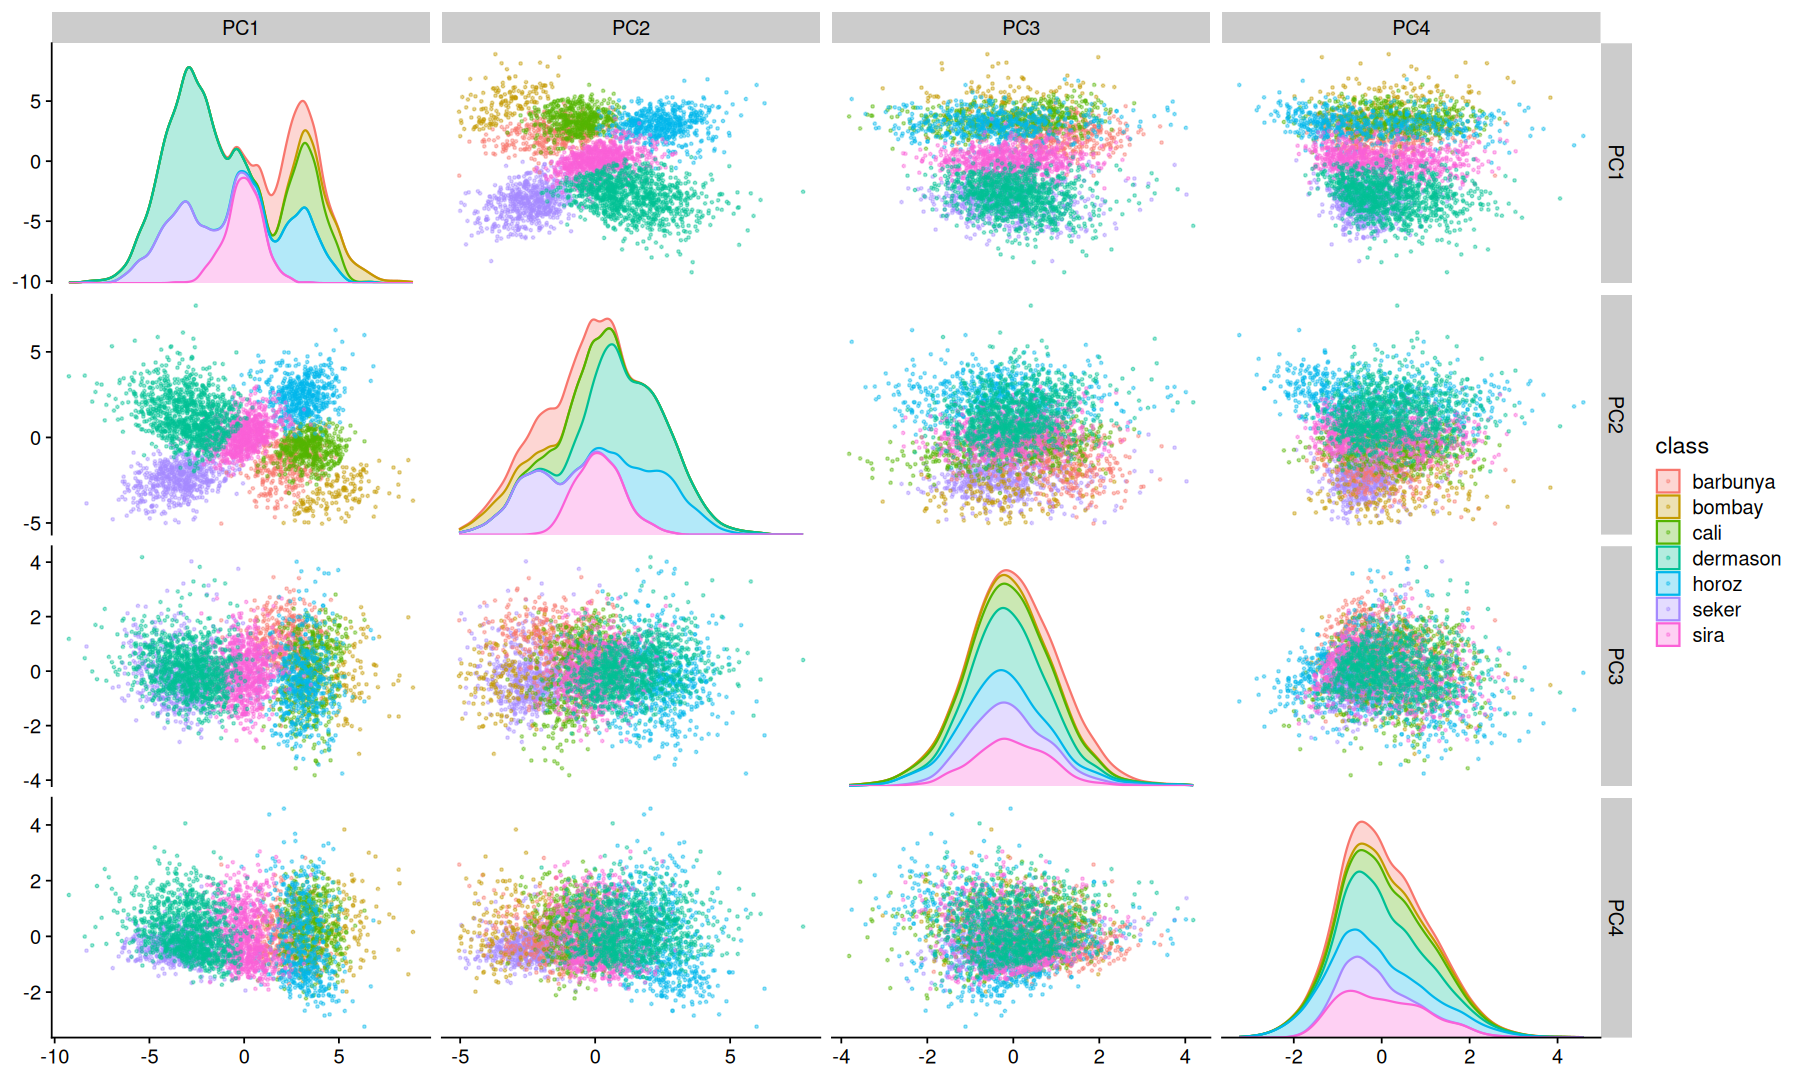

In [9]:
rec |>
step_pca(all_predictors(), num_comp = 4) |>
plot_rec(class, test)

# PLS

Partial Least Squares regression is a supervised technique similar to PCA, it finds a linear regression model by projecting the predicted variables and the observable variables to a new space of maximum covariance.

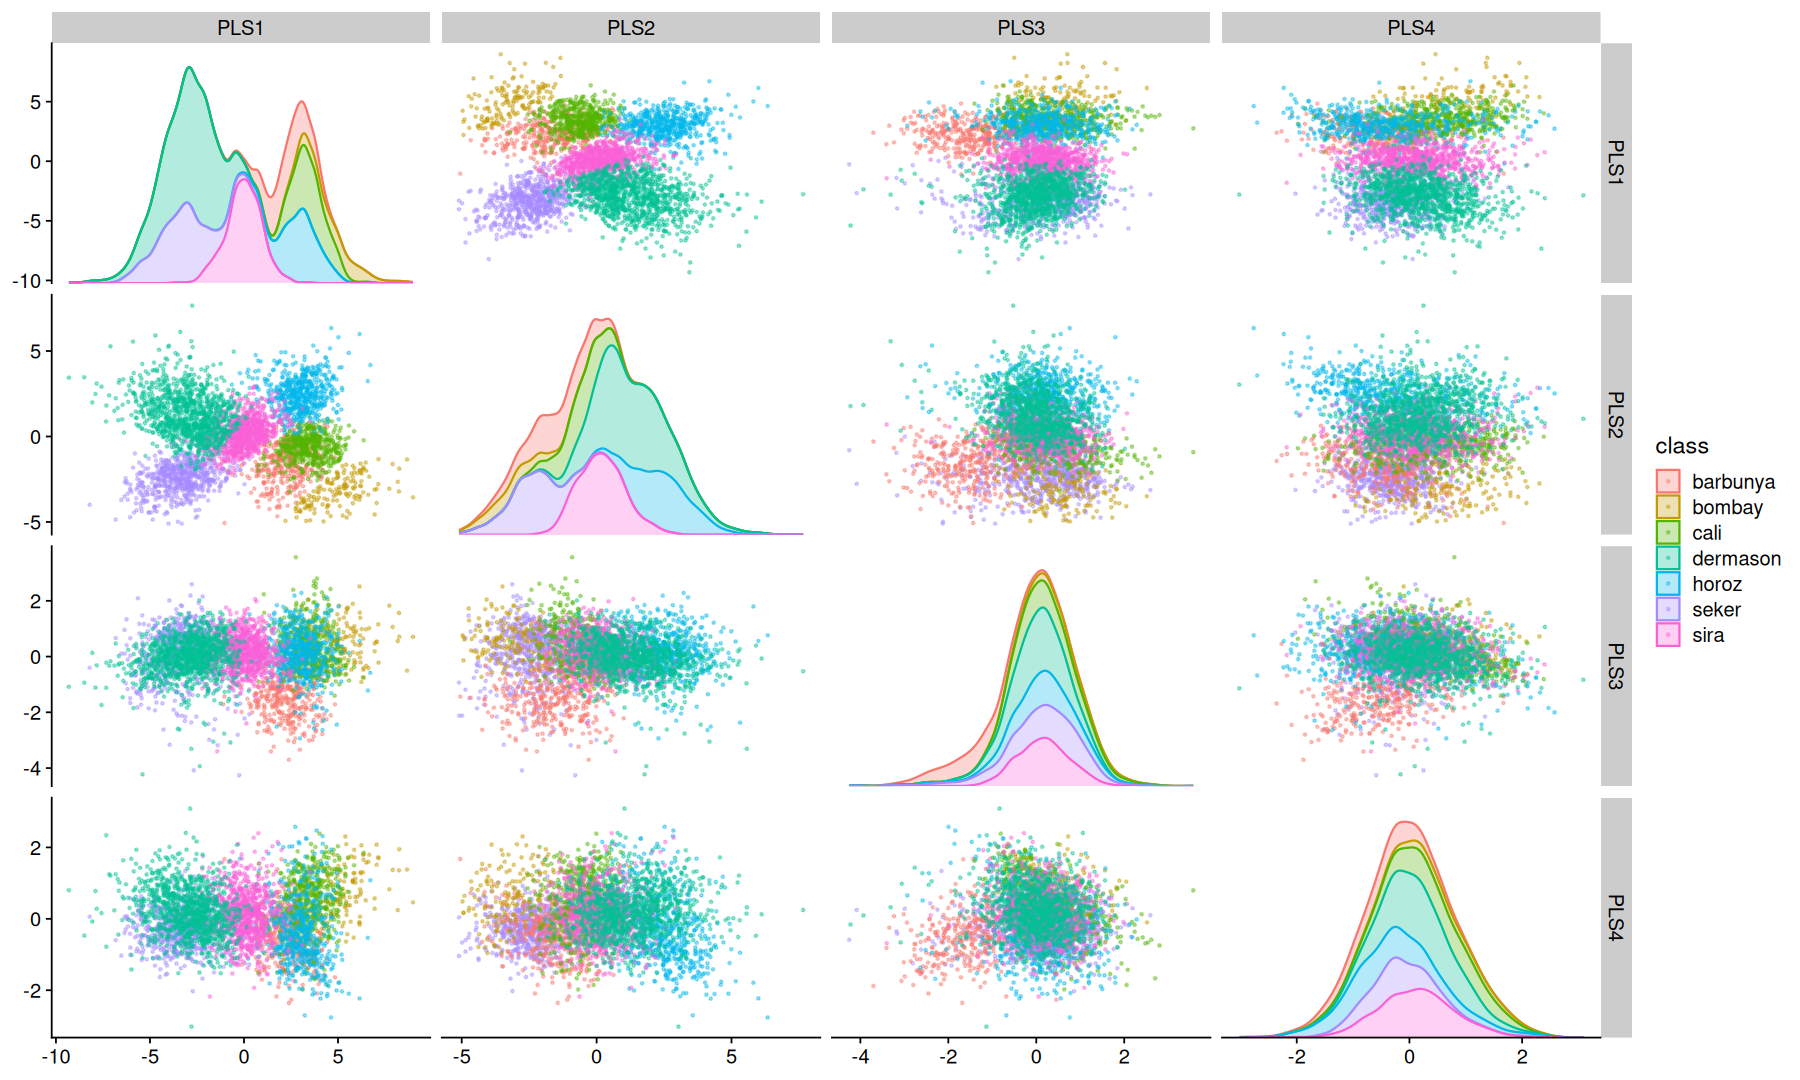

In [10]:
rec |>
step_pls(all_predictors(), outcome='class', num_comp = 4) |>
plot_rec(class, test)

# ICA

Independent Component Analysis is a computational method for separating a signal into additive subcomponents. This is done by assuming that at most one subcomponent is Gaussian and that the subcomponents are statistically independent from each other.

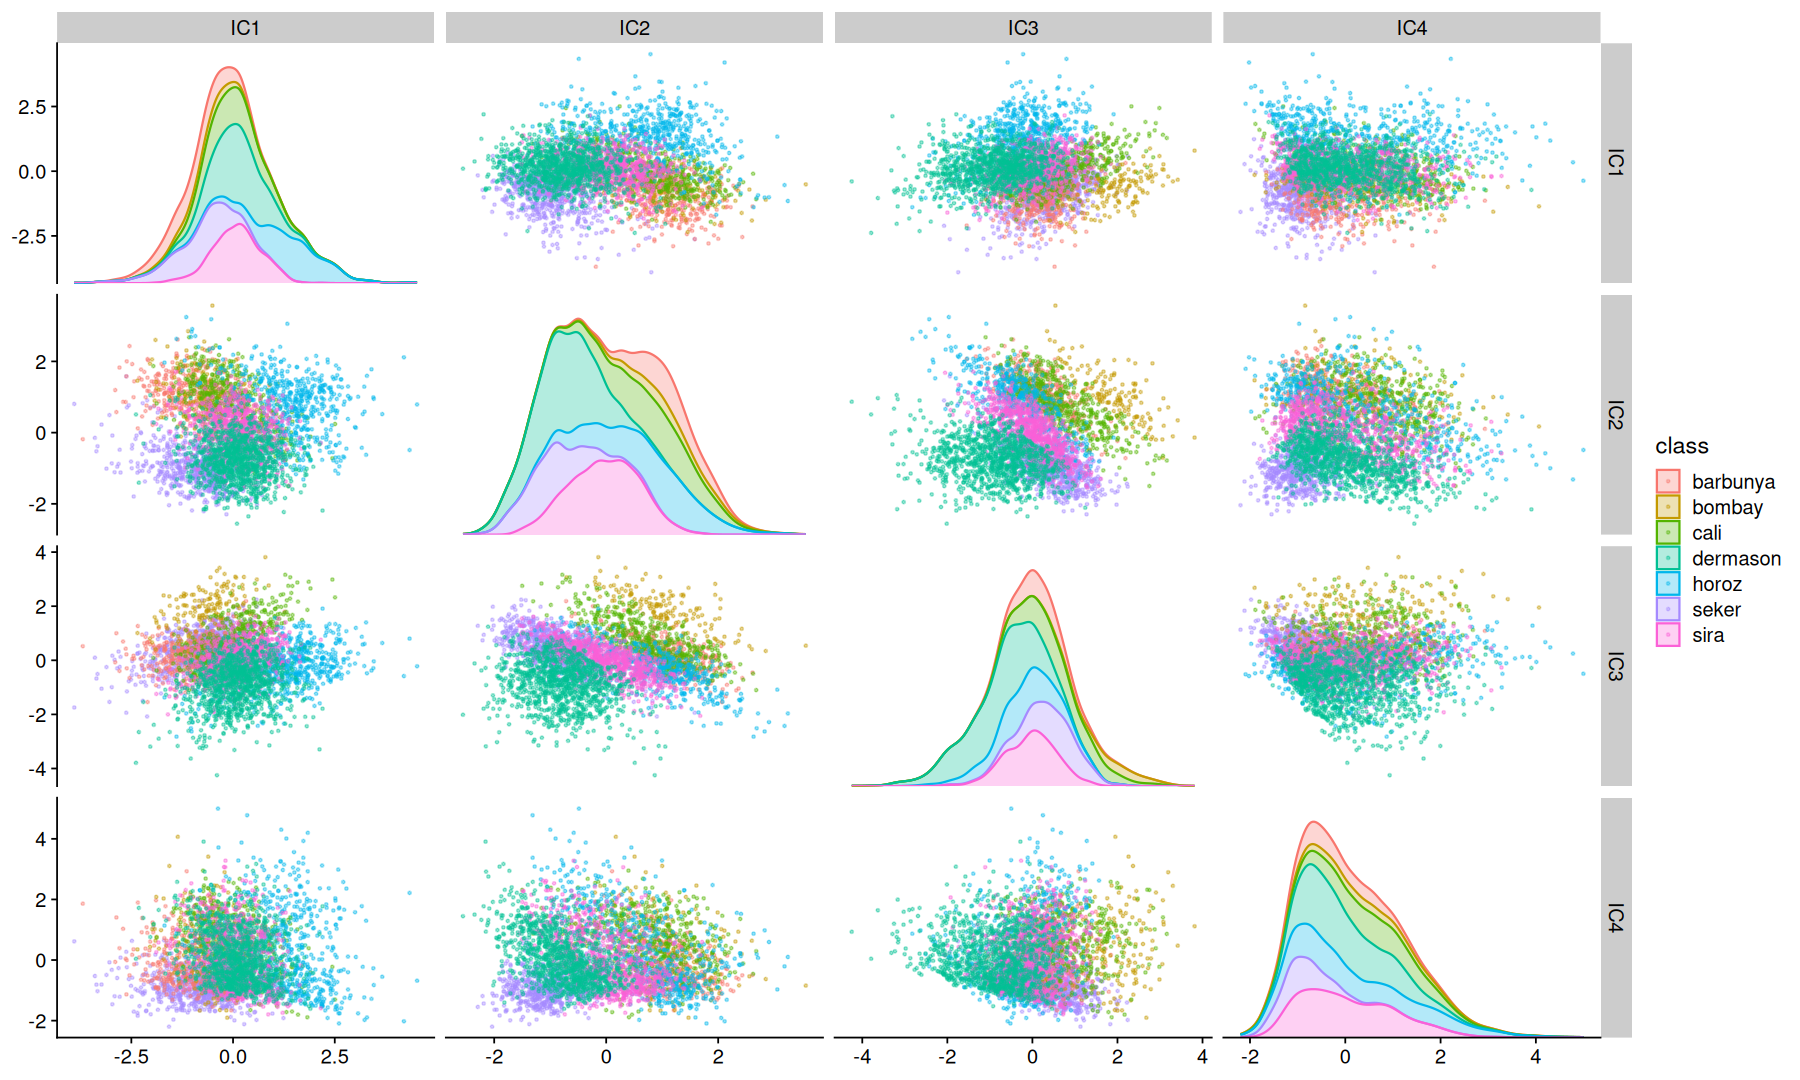

In [11]:
rec |>
step_ica(all_predictors(), num_comp = 4) |>
plot_rec(class, test)

# UMAP

Uniform Manifold Approximation and Projection is a dimension reduction technique that can be used for visualisation similarly to t-SNE, but also for general non-linear dimension reduction.

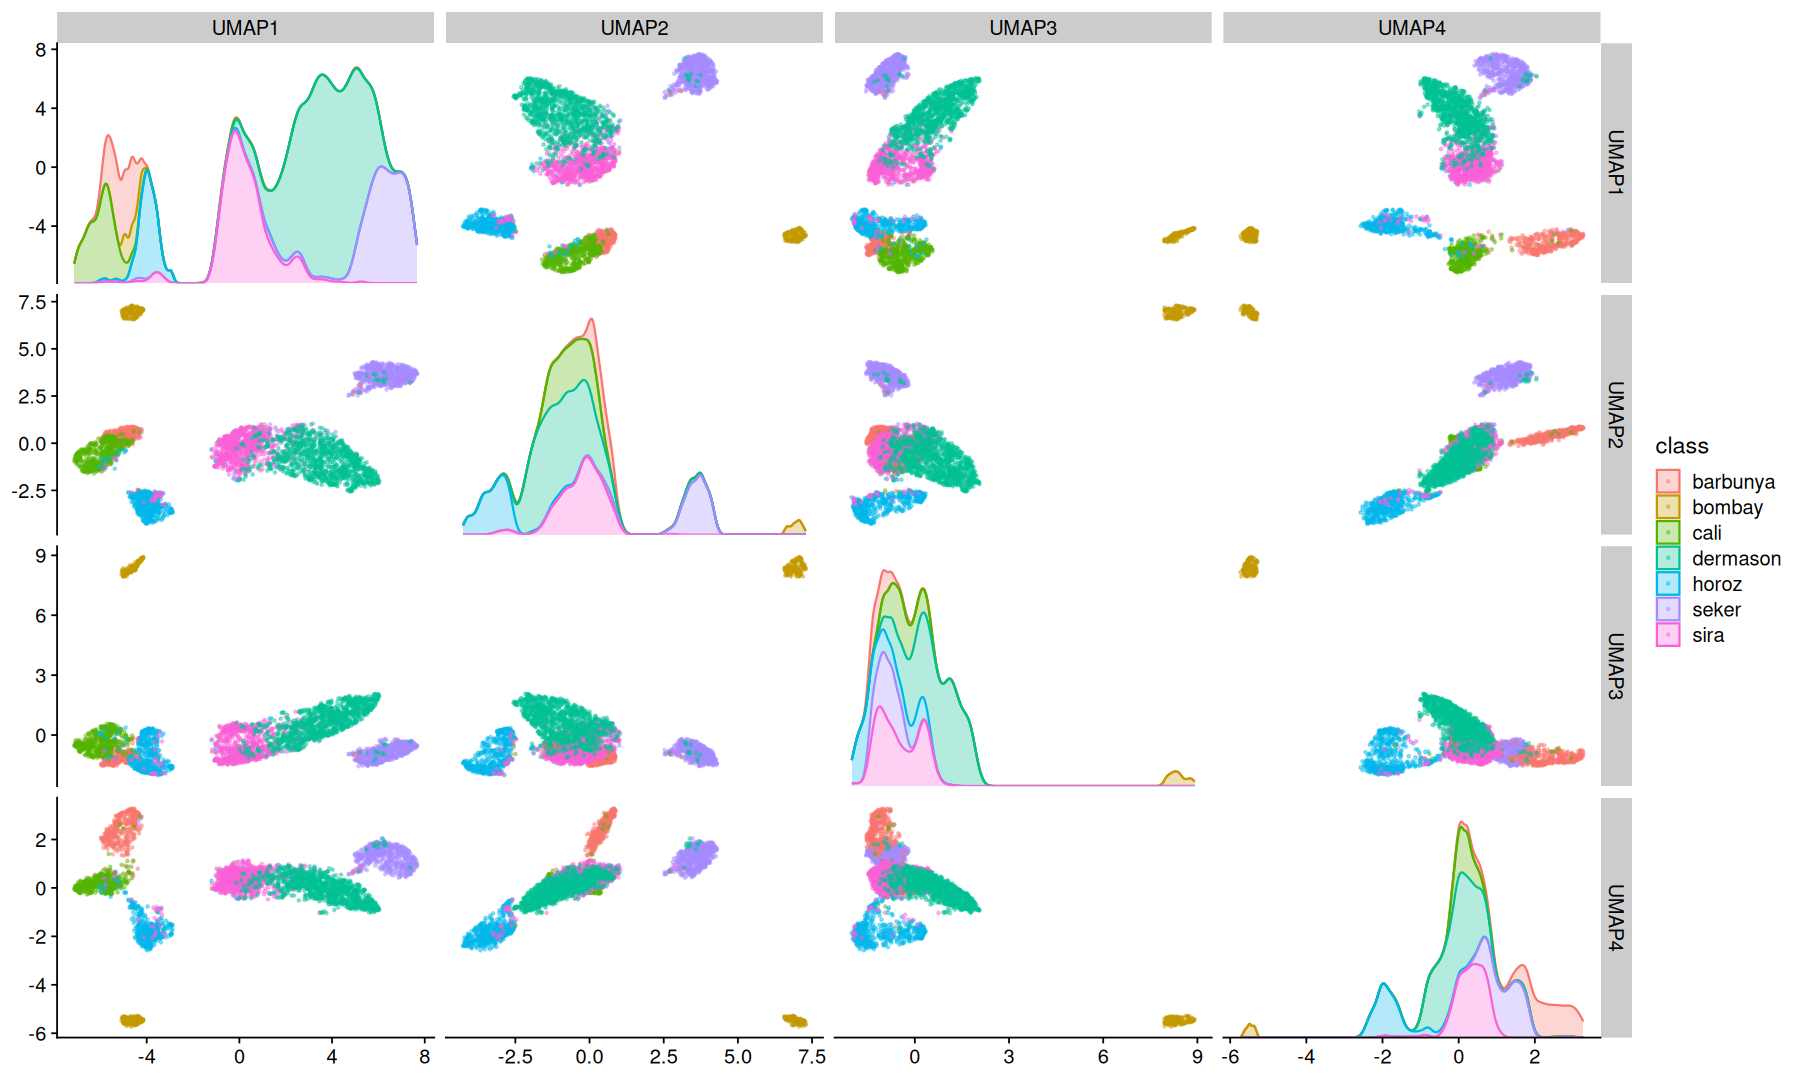

In [12]:
rec |>
step_umap(all_predictors(), num_comp = 4) |>
plot_rec(class, test)

UMAP can also to make use of a label information to perform supervised dimension reduction.

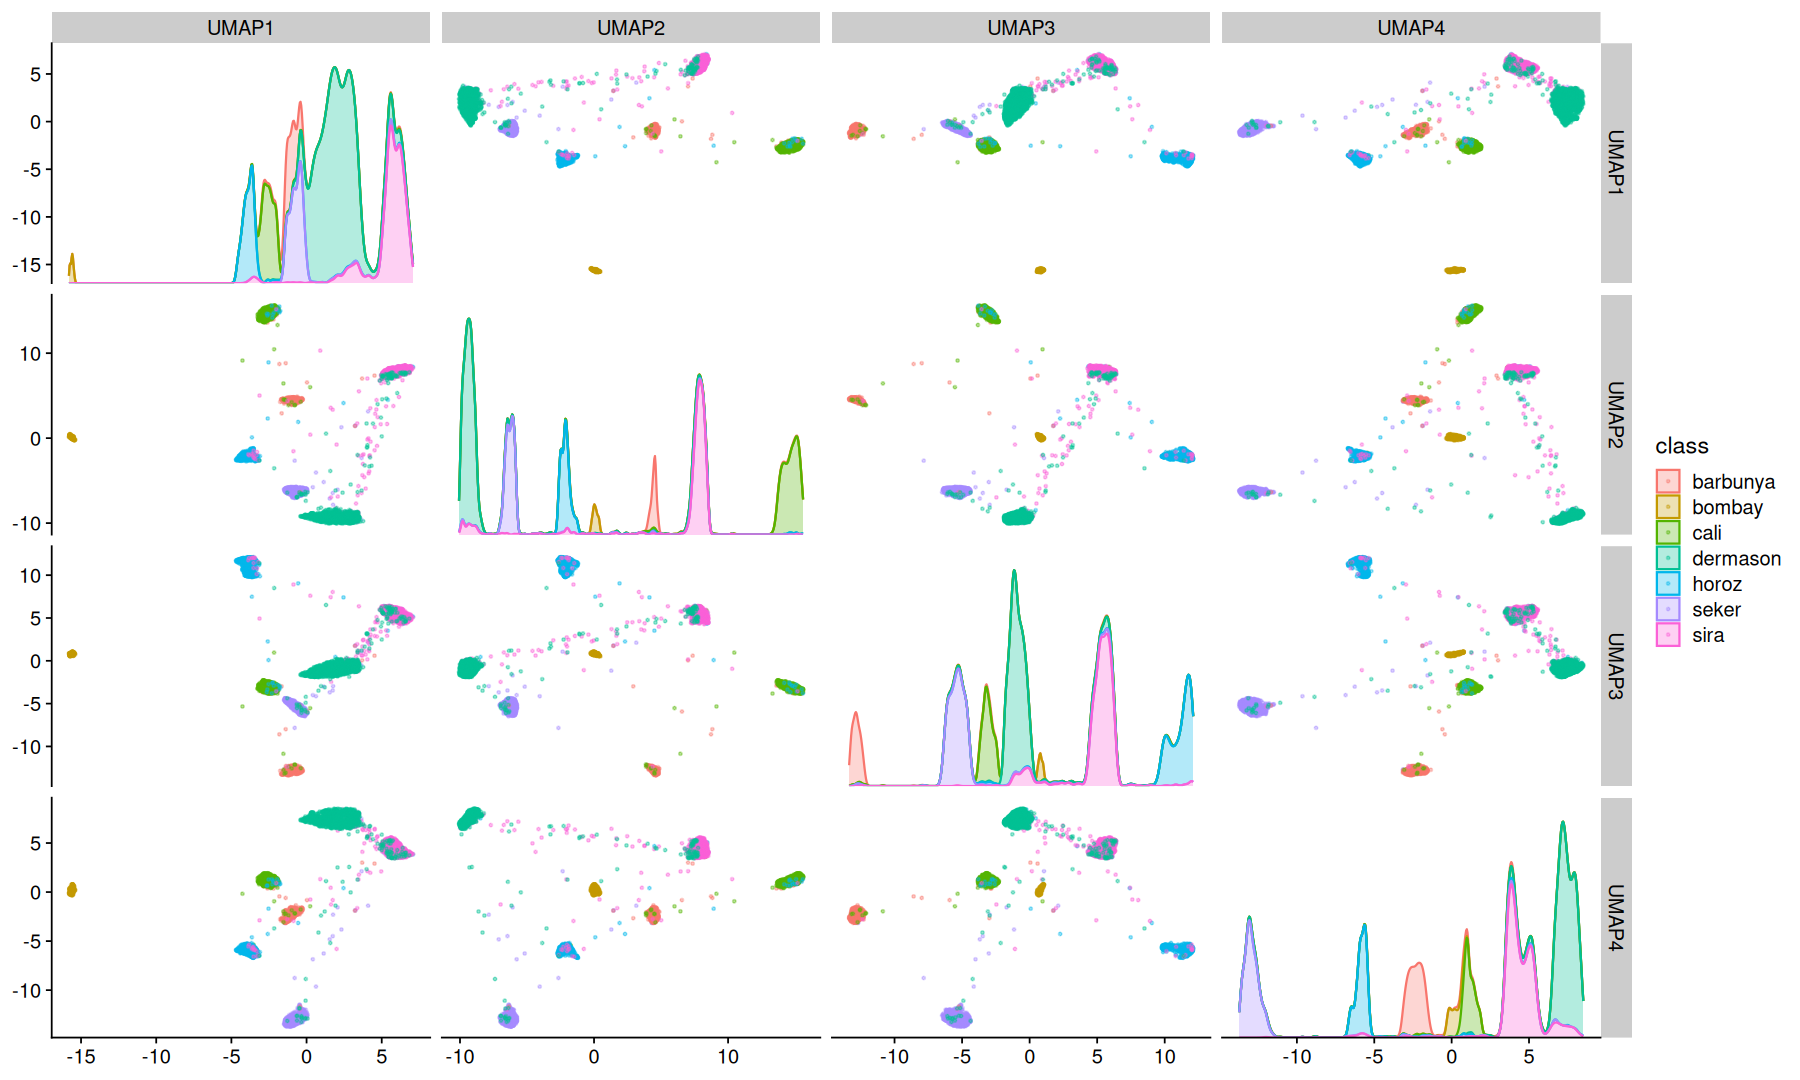

In [13]:
rec |>
step_umap(all_predictors(), outcome=vars(class), num_comp = 4) |>
plot_rec(class, test)

# NMF

Non-negative Matrix Factorization is a technique to factorize a matrix V into two matrices W and H, such that W * H = V, with the property that all three matrices have no negative elements.

Note that for demonstration purposes the data was transformed to be within 0 and 1, in practice if your data have negative numbers NMF is not a good fit.

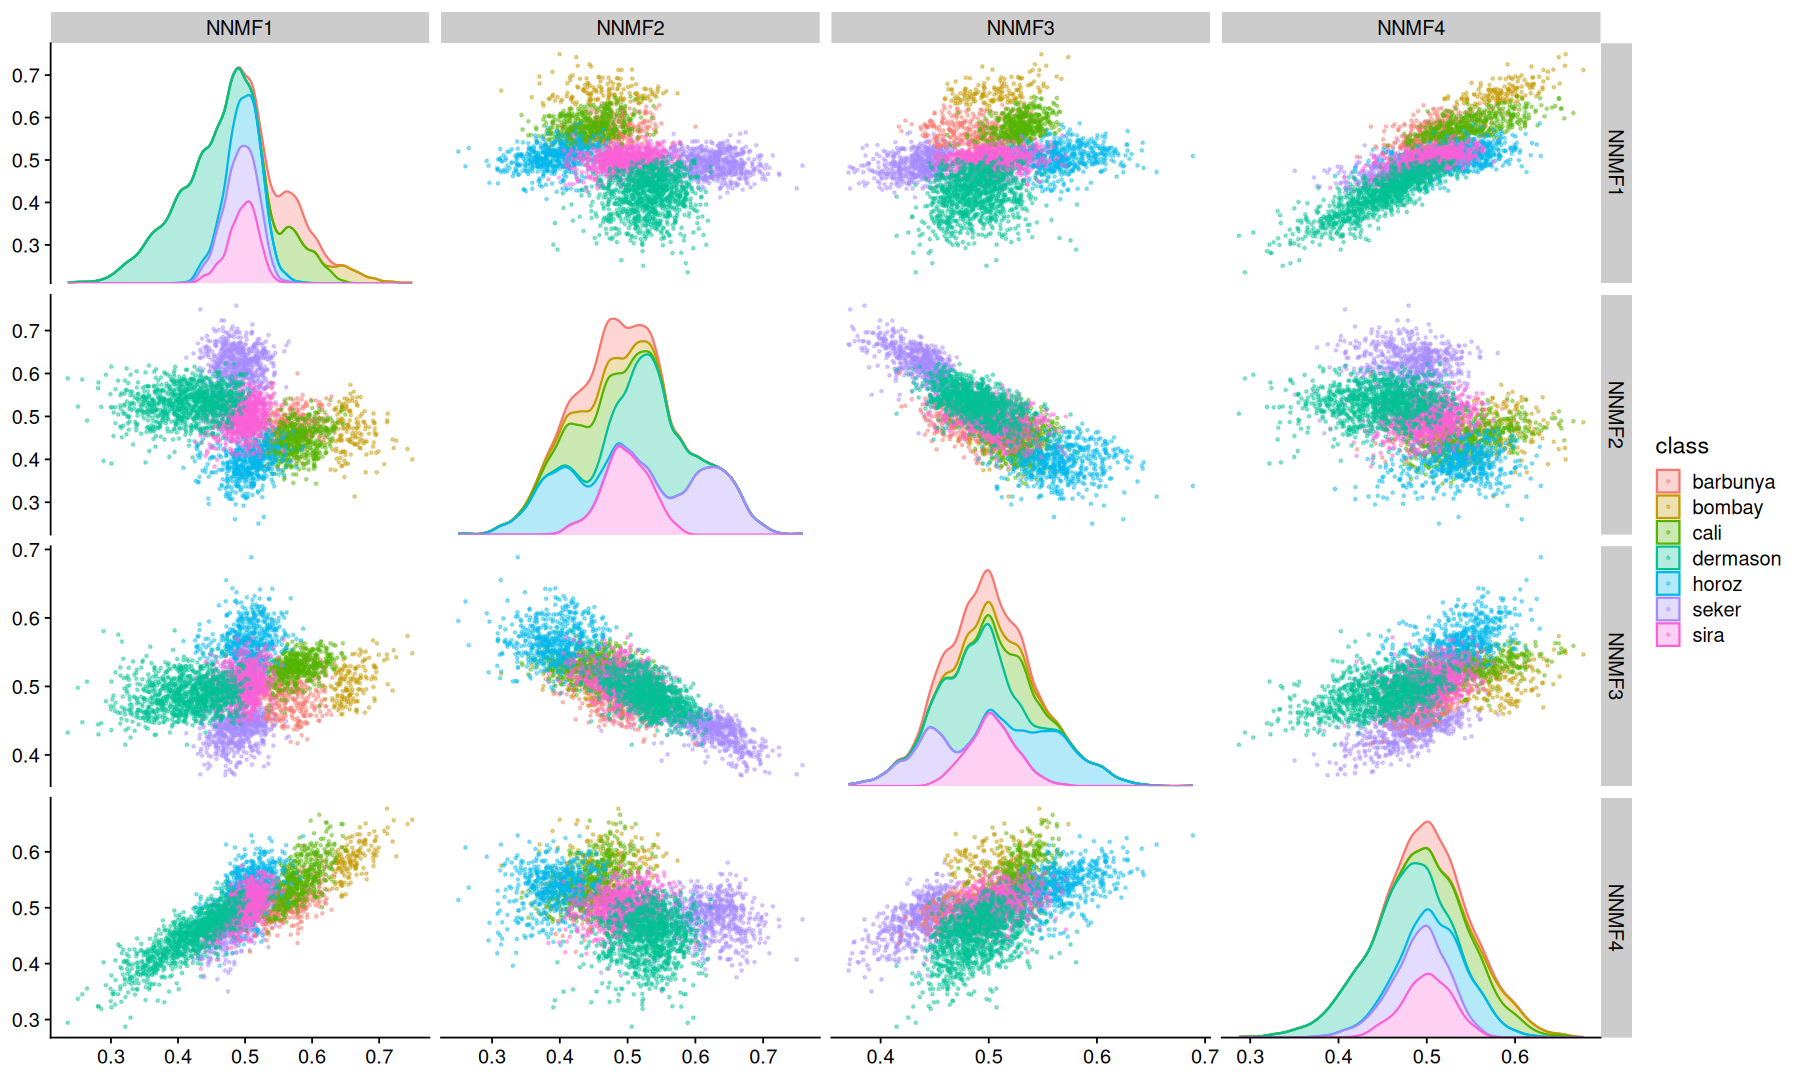

In [14]:
rec |>
# transform data to be non-negative
step_range(all_predictors(), min=0, max=1, clipping = FALSE) |>
step_nnmf_sparse(all_predictors(), num_comp = 4) |>
plot_rec(class, test)

# Further reading

https://www.tmwr.org/dimensionality